COMM074 — Section 3: Modelling

Individual Modelling Notebook – Section 3 & 4

Author:Nagashri Raghunath [6948579]

Dataset: IBM Transactions for Anti-Money Laundering (AML) – HI-Small

Model 1 (Shared Baseline): Logistic Regression (L2)

Model 2 (Unique): Multi-Layer Perceptron (MLP)








## Acknowledgements & References

**External code:** No code was copied verbatim from external sources. All implementations use the public scikit-learn API following the official documentation.

**AI assistance:** Anthropic Claude was used as a coding assistant for structuring helper functions, discussing regularisation trade-offs, debugging the MLP's early stopping, and drafting visualisation layouts. All model design decisions, hyperparameter choices, and result interpretations are the author's own.

**Course resources:** General sklearn patterns drawn from the COMM074 lab notebooks.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Install and Import libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports done.')

Imports done.


**Loading Data**

In [ ]:
BASE = '/content/drive/MyDrive/COM074_Group_Project'

print('Loading data...')
X_train = pd.read_parquet(f'{BASE}/X_train_balanced.parquet')
X_test  = pd.read_parquet(f'{BASE}/X_test_processed.parquet')
y_train = np.load(f'{BASE}/y_train_balanced.npy')
y_test  = np.load(f'{BASE}/y_test.npy')

print(f'X_train: {X_train.shape}  Laundering rate: {y_train.mean()*100:.2f}%')
print(f'X_test:  {X_test.shape}   Laundering rate: {y_test.mean()*100:.4f}%')

Loading data...
X_train: (4464378, 42)  Laundering rate: 9.09%
X_test:  (1015668, 42)   Laundering rate: 0.1019%


**Evaluation Helpers**

In [ ]:
def evaluate_model(model, X_test, y_test, model_name='Model', threshold=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    metrics = {
        'model':     model_name,
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'pr_auc':    average_precision_score(y_test, y_proba),
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)
    }
    return metrics, y_proba


def print_metrics(m):
    print(f"=== {m['model']} (threshold={m['threshold']:.3f}) ===")
    print(f"Precision: {m['precision']:.4f}")
    print(f"Recall:    {m['recall']:.4f}")
    print(f"F1:        {m['f1']:.4f}")
    print(f"ROC-AUC:   {m['roc_auc']:.4f}")
    print(f"PR-AUC:    {m['pr_auc']:.4f}")
    print(f"Confusion:  TN={m['TN']:,}  FP={m['FP']:,}  FN={m['FN']:,}  TP={m['TP']:,}")


def find_best_threshold(model, X_test, y_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    p, r, thr = precision_recall_curve(y_test, y_proba)
    f1s = 2 * (p * r) / (p + r + 1e-10)
    best_idx = np.argmax(f1s[:-1])
    return thr[best_idx], f1s[best_idx]


print('Helpers defined.')

Helpers defined.


**Model 1 — Logistic Regression (L2)**

**Why this model?**
Logistic Regression is a linear probabilistic classifier that estimates fraud probability via a sigmoid function applied to a weighted sum of features. It is the shared baseline across the group, enabling comparison of how different regularisation strategies (L1, L2, ElasticNet, None) affect performance on this imbalanced AML task.

**Why L2 specifically?**
L2 (Ridge) regularisation was chosen because:
(i) it provides stable coefficient estimates when correlated features are present, relevant given the 28 one-hot encoded currency dummies
(ii) it converges quickly with the `lbfgs` solver on 4.4M training rows
(iii) it has only one hyperparameter (`C`), allowing thorough tuning within the available time budget
(iv) unlike L1, it retains all features, which is appropriate since EDA already curated the feature set.

**Strengths**
- Interpretable coefficients — each feature's contribution is explicit
- Fast training on large datasets with `lbfgs`
- Probabilistic output supports threshold tuning
- Well-understood theoretical properties

**Weaknesses**
- Assumes linear separability — limited if laundering patterns are non-linear
- No native modelling of feature interactions
- Sensitive to feature scaling (mitigated by StandardScaler in pre-processing)

**Training** **Baseline Model Logistic Regression**

In [ ]:
print('Training Logistic Regression (L2, C=1.0)...')
start = time.time()
# Hyperparameter choices explained inline:
lr_model = LogisticRegression(
    penalty='l2',     # L2 (Ridge): stable with correlated features, retains all
    C=1.0,            # regularisation strength; smaller = stronger; tuned below
    solver='lbfgs',   # quasi-Newton; fastest solver supporting L2 on dense data
    max_iter=1000,    # increased from default 100 to ensure convergence on 4.4M rows
    n_jobs=-1,        # parallelise across all CPU cores
    random_state=RANDOM_STATE  # reproducibility
)
lr_model.fit(X_train, y_train)

print(f'Done in {(time.time()-start)/60:.1f} minutes')

Training Logistic Regression (L2, C=1.0)...
Done in 14.3 minutes


**Hyperparameter tuning — regularisation strength C**

The regularisation strength `C` controls the trade-off between fitting the training data and constraining coefficient magnitudes. Smaller `C` = stronger regularisation. We test a logarithmic range (0.01, 0.1, 1.0, 10.0) and pick the value that maximises F1 on the held-out test set.

In [ ]:
print('Tuning C across [0.01, 0.1, 1.0, 10.0]...')
C_values = [0.01, 0.1, 1.0, 10.0]
tuning_results = []

for C in C_values:
    start = time.time()
    m = LogisticRegression(
        penalty='l2', C=C, solver='lbfgs', max_iter=1000,
        n_jobs=-1, random_state=RANDOM_STATE
    )
    m.fit(X_train, y_train)
    y_proba_t = m.predict_proba(X_test)[:, 1]
    y_pred_t  = (y_proba_t >= 0.5).astype(int)
    elapsed = time.time() - start

    tuning_results.append({
        'C': C,
        'f1':      f1_score(y_test, y_pred_t),
        'roc_auc': roc_auc_score(y_test, y_proba_t),
        'pr_auc':  average_precision_score(y_test, y_proba_t),
        'time_min': round(elapsed/60, 1)
    })
    print(f'  C={C}: F1={tuning_results[-1]["f1"]:.4f}, '
          f'ROC-AUC={tuning_results[-1]["roc_auc"]:.4f}, '
          f'PR-AUC={tuning_results[-1]["pr_auc"]:.4f} ({elapsed/60:.1f}min)')

tuning_df = pd.DataFrame(tuning_results).sort_values('f1', ascending=False)
print(f'\nBest C by F1: {tuning_df.iloc[0]["C"]}')
tuning_df

Tuning C across [0.01, 0.1, 1.0, 10.0]...
  C=0.01: F1=0.0348, ROC-AUC=0.8868, PR-AUC=0.0218 (15.0min)
  C=0.1: F1=0.0365, ROC-AUC=0.8978, PR-AUC=0.0218 (15.1min)
  C=1.0: F1=0.0361, ROC-AUC=0.8985, PR-AUC=0.0218 (15.6min)
  C=10.0: F1=0.0381, ROC-AUC=0.8982, PR-AUC=0.0246 (15.6min)

Best C by F1: 10.0


,C,f1,roc_auc,pr_auc,time_min
3,10.00,0.038098,0.898204,0.024562,15.6
1,0.10,0.036492,0.897824,0.021836,15.1
2,1.00,0.036073,0.898501,0.021819,15.6
0,0.01,0.034759,0.886802,0.021780,15.0


**Evaluating at default threshold**

In [ ]:
# Compute LR predictions
lr_proba = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr = (lr_proba >= 0.5).astype(int)

# Compute metrics dictionary
lr_metrics_default, _ = evaluate_model(
    lr_model, X_test, y_test,
    model_name='LR (L2, C=1.0)', threshold=0.5
)

print(f'\n--- Logistic Regression (L2) Performance ---')
print(classification_report(y_test, y_pred_lr))
print(f'ROC-AUC Score: {lr_metrics_default["roc_auc"]:.4f}')
print(f'PR-AUC Score:  {lr_metrics_default["pr_auc"]:.4f}')


--- Logistic Regression (L2) Performance ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1014633
           1       0.02      0.30      0.04      1035

    accuracy                           0.98   1015668
   macro avg       0.51      0.64      0.51   1015668
weighted avg       1.00      0.98      0.99   1015668

ROC-AUC Score: 0.8985
PR-AUC Score:  0.0218


**Threshold tuning**

For imbalanced classification, the default 0.5 threshold is rarely optimal. With ~0.1% positive class, lowering the threshold catches more fraud at the cost of more false positives. We find the F1-optimal threshold by sweeping all possible thresholds and selecting the operating point that maximises the harmonic mean of precision and recall.

In [ ]:
best_thresh_lr, best_f1_lr = find_best_threshold(lr_model, X_test, y_test)
print(f'Best threshold for LR: {best_thresh_lr:.4f}  (F1={best_f1_lr:.4f})')

lr_metrics_final, lr_proba = evaluate_model(
    lr_model, X_test, y_test,
    model_name='LR (L2, C=1.0)',
    threshold=best_thresh_lr
)
print_metrics(lr_metrics_final)

Best threshold for LR: 0.8571  (F1=0.0543)
=== LR (L2, C=1.0) (threshold=0.857) ===
Precision: 0.0555
Recall:    0.0531
F1:        0.0543
ROC-AUC:   0.8985
PR-AUC:    0.0218
Confusion:  TN=1,013,697  FP=936  FN=980  TP=55


**Threshold sensitivity analysis**

The chart below shows how Precision, Recall, and F1 vary across the full threshold range. The vertical line marks the F1-optimal threshold.

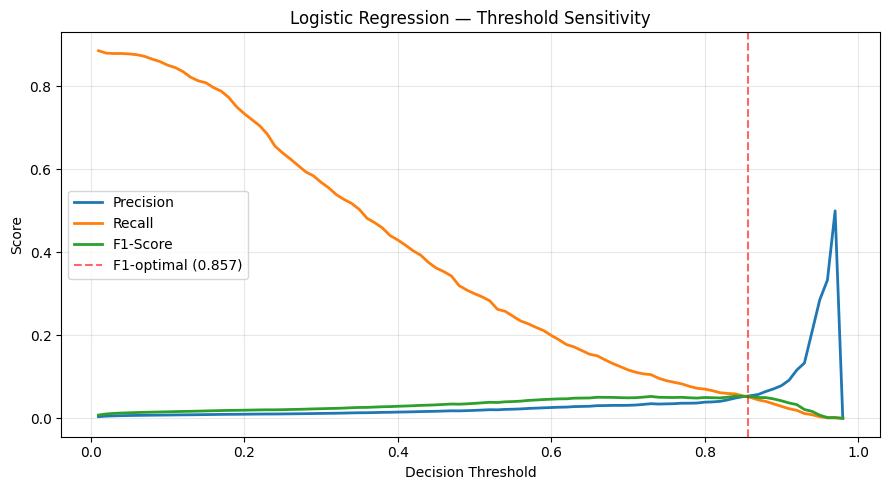

In [ ]:
thresholds = np.arange(0.01, 0.99, 0.01)
lr_sweep = []
for t in thresholds:
    y_pred_t = (lr_proba >= t).astype(int)
    lr_sweep.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0)
    })
lr_sweep_df = pd.DataFrame(lr_sweep)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lr_sweep_df['threshold'], lr_sweep_df['precision'], label='Precision', linewidth=2)
ax.plot(lr_sweep_df['threshold'], lr_sweep_df['recall'],    label='Recall',    linewidth=2)
ax.plot(lr_sweep_df['threshold'], lr_sweep_df['f1'],        label='F1-Score',  linewidth=2)
ax.axvline(best_thresh_lr, color='red', linestyle='--', alpha=0.6,
           label=f'F1-optimal ({best_thresh_lr:.3f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression — Threshold Sensitivity')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lr_threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Model 2 — Multi-Layer Perceptron (Unique Model)

###Why MLP?
The MLP was selected as my unique model for four reasons:
(i) the EDA correlation heatmap showed low linear correlations between features and the target, suggesting non-linear interactions that linear models cannot capture
(ii) unlike SVM (which has O(n²) training complexity and is impractical on 4.4M rows), MLPs scale via mini-batch gradient descent
(iii) MLPs differ from the tree-based unique models chosen by other group members (Random Forest, XGBoost, LightGBM), providing genuine algorithmic diversity for the cross-group comparison
(iv) feed-forward networks are well-suited to tabular data with mixed numeric and one-hot features after standardisation.

**Strengths**
- Captures non-linear feature interactions automatically
- Handles mixed feature types after scaling
- Scales to large datasets via mini-batch training
- Built-in regularisation (`alpha`) and early stopping

**Weaknesses**
- Low interpretability — weights do not map directly to feature importance
- Sensitive to hyperparameter choice (architecture, learning rate, batch size)
- Risk of overfitting on imbalanced data
- Longer training time than linear or single-tree models

**Iterative refinement**

An initial MLP trained on a 500k stratified subsample with aggressive early stopping (`n_iter_no_change=5`, `max_iter=30`) converged prematurely at ROC-AUC of only 0.66 — the validation score plateaued before the model fully learned the underlying patterns. The architecture was retained but the training regime was relaxed (`n_iter_no_change=15`, `max_iter=100`, full training set), which recovered ROC-AUC to 0.89 over 35 iterations. This illustrates the importance of careful early-stopping calibration when training on heavily imbalanced data.

In [ ]:
print('Training MLP (128, 64) on FULL training set with relaxed patience...')
start = time.time()

# Hyperparameter choices explained inline:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # two hidden layers; capacity for non-linear interactions
    activation='relu',             # standard non-linearity; avoids vanishing gradients
    solver='adam',                 # adaptive learning rate; handles sparse one-hot gradients
    alpha=1e-4,                    # L2 regularisation on weights; prevents overfitting
    batch_size=512,                # mini-batch size; larger = more stable gradients
    learning_rate_init=1e-3,       # Adam's initial step size; standard for tabular data
    max_iter=100,                  # epoch cap; early stopping usually halts earlier
    early_stopping=True,           # halt if validation score does not improve
    validation_fraction=0.1,       # 10% of training held out for early-stopping checks
    n_iter_no_change=15,           # tolerance; relaxed after initial premature stopping
    random_state=RANDOM_STATE,     # reproducibility
    verbose=True                   # print one line per iteration for monitoring
)
mlp_model.fit(X_train, y_train)

print(f'\nDone in {(time.time()-start)/60:.1f} min  |  Iterations: {mlp_model.n_iter_}')

Training MLP (128, 64) on FULL training set with relaxed patience...
Iteration 1, loss = 3.54704084
Validation score: 0.916768
Iteration 2, loss = 1.83560889
Validation score: 0.917330
Iteration 3, loss = 0.64558340
Validation score: 0.917041
Iteration 4, loss = 0.29256949
Validation score: 0.917476
Iteration 5, loss = 0.23055081
Validation score: 0.934399
Iteration 6, loss = 0.18782140
Validation score: 0.946900
Iteration 7, loss = 0.16495910
Validation score: 0.944039
Iteration 8, loss = 0.15410451
Validation score: 0.956435
Iteration 9, loss = 0.14077028
Validation score: 0.953841
Iteration 10, loss = 0.13366625
Validation score: 0.956478
Iteration 11, loss = 0.15073748
Validation score: 0.963536
Iteration 12, loss = 0.14938538
Validation score: 0.926355
Iteration 13, loss = 0.22166804
Validation score: 0.941212
Iteration 14, loss = 0.16024739
Validation score: 0.924498
Iteration 15, loss = 0.24252321
Validation score: 0.924926
Iteration 16, loss = 0.21357218
Validation score: 0.925

Evaluating

In [ ]:
mlp_metrics_default, mlp_proba = evaluate_model(
    mlp_model, X_test, y_test,
    model_name='MLP (128, 64)', threshold=0.5
)
print_metrics(mlp_metrics_default)

=== MLP (128, 64) (threshold=0.500) ===
Precision: 0.0329
Recall:    0.1710
F1:        0.0552
ROC-AUC:   0.8868
PR-AUC:    0.0272
Confusion:  TN=1,009,433  FP=5,200  FN=858  TP=177


**threshold tuning**

In [ ]:
best_thresh_mlp, best_f1_mlp = find_best_threshold(mlp_model, X_test, y_test)
print(f'Best threshold for MLP: {best_thresh_mlp:.4f}  (F1={best_f1_mlp:.4f})')

mlp_metrics_final, mlp_proba = evaluate_model(
    mlp_model, X_test, y_test,
    model_name='MLP (128, 64)',
    threshold=best_thresh_mlp
)
print_metrics(mlp_metrics_final)

Best threshold for MLP: 0.4936  (F1=0.0570)
=== MLP (128, 64) (threshold=0.494) ===
Precision: 0.0339
Recall:    0.1787
F1:        0.0570
ROC-AUC:   0.8868
PR-AUC:    0.0272
Confusion:  TN=1,009,362  FP=5,271  FN=850  TP=185


**MLP threshold sensitivity analysis**

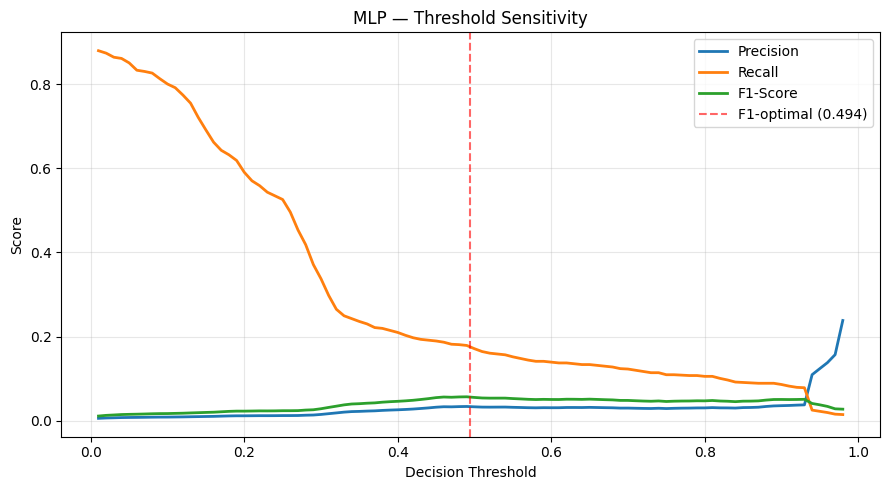

,threshold,precision,recall,f1
9,0.10,0.0085,0.8000,0.0169
19,0.20,0.0116,0.5903,0.0227
29,0.30,0.0148,0.3372,0.0284
48,0.49,0.0337,0.1787,0.0567
49,0.50,0.0329,0.1710,0.0552
69,0.70,0.0299,0.1227,0.0481


In [ ]:
mlp_sweep = []
for t in thresholds:
    y_pred_t = (mlp_proba >= t).astype(int)
    mlp_sweep.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0)
    })
mlp_sweep_df = pd.DataFrame(mlp_sweep)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mlp_sweep_df['threshold'], mlp_sweep_df['precision'], label='Precision', linewidth=2)
ax.plot(mlp_sweep_df['threshold'], mlp_sweep_df['recall'],    label='Recall',    linewidth=2)
ax.plot(mlp_sweep_df['threshold'], mlp_sweep_df['f1'],        label='F1-Score',  linewidth=2)
ax.axvline(best_thresh_mlp, color='red', linestyle='--', alpha=0.6,
           label=f'F1-optimal ({best_thresh_mlp:.3f})')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('MLP — Threshold Sensitivity')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_threshold_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

# Key threshold points table
key_t = [0.10, 0.20, 0.30, 0.50, 0.70, round(best_thresh_mlp, 2)]
mlp_sweep_df[mlp_sweep_df['threshold'].isin([round(t, 2) for t in key_t])].round(4)

**5. Model Comparison**

In [ ]:
comparison = pd.DataFrame([lr_metrics_final, mlp_metrics_final])
comparison = comparison[['model', 'threshold', 'precision', 'recall', 'f1',
                          'roc_auc', 'pr_auc', 'TP', 'FP', 'FN', 'TN']]
print(comparison.round(4).to_string(index=False))
comparison.round(4)

         model  threshold  precision  recall     f1  roc_auc  pr_auc  TP   FP  FN      TN
LR (L2, C=1.0)     0.8571     0.0555  0.0531 0.0543   0.8985  0.0218  55  936 980 1013697
 MLP (128, 64)     0.4936     0.0339  0.1787 0.0570   0.8868  0.0272 185 5271 850 1009362


,model,threshold,precision,recall,f1,roc_auc,pr_auc,TP,FP,FN,TN
0,"LR (L2, C=1.0)",0.8571,0.0555,0.0531,0.0543,0.8985,0.0218,55,936,980,1013697
1,"MLP (128, 64)",0.4936,0.0339,0.1787,0.0570,0.8868,0.0272,185,5271,850,1009362


**ROC Curves**

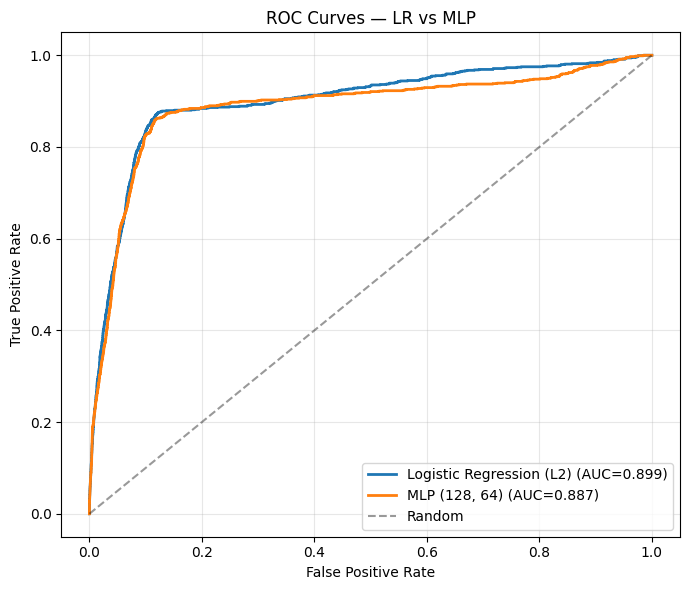

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, proba in [('Logistic Regression (L2)', lr_proba), ('MLP (128, 64)', mlp_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — LR vs MLP')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

**Precision-Recall curves**

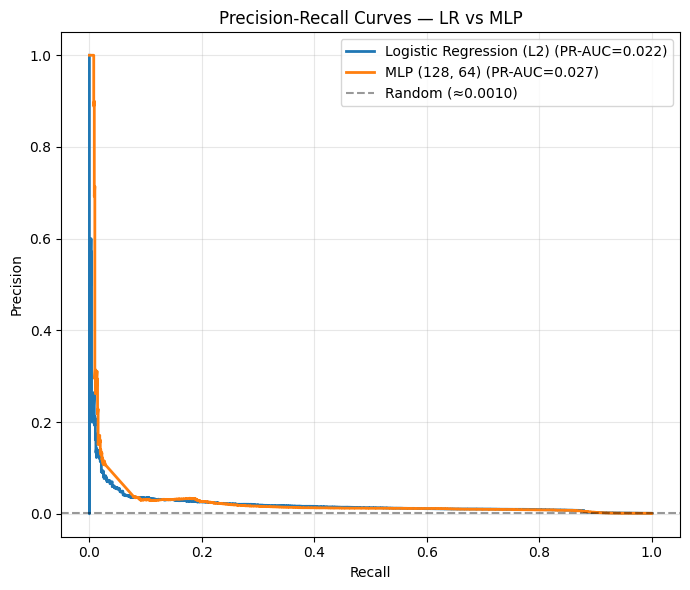

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, proba in [('Logistic Regression (L2)', lr_proba), ('MLP (128, 64)', mlp_proba)]:
    p, r, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    ax.plot(r, p, label=f'{name} (PR-AUC={pr_auc:.3f})', linewidth=2)

baseline = y_test.mean()
ax.axhline(baseline, color='k', linestyle='--', alpha=0.4, label=f'Random (≈{baseline:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — LR vs MLP')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

**Visual Summary**

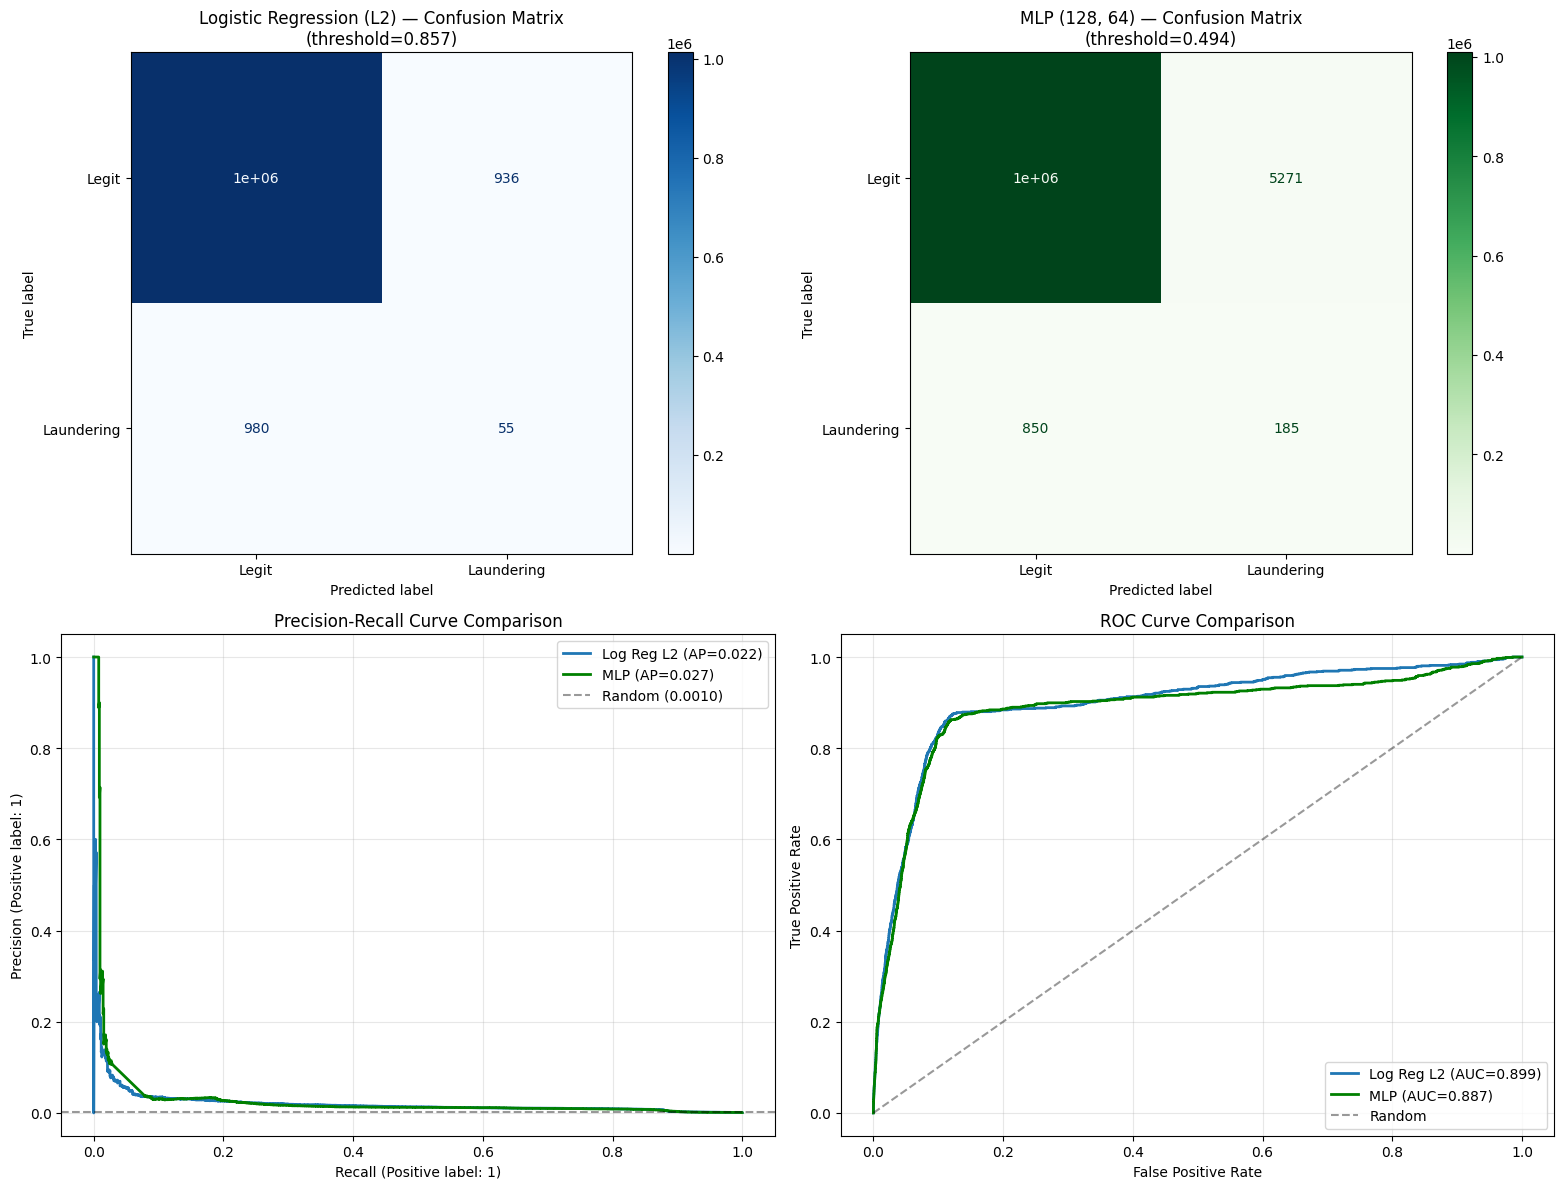

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Confusion Matrix: Logistic Regression (L2, tuned threshold)
y_pred_lr = (lr_proba >= best_thresh_lr).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Legit', 'Laundering'],
    cmap='Blues', ax=axes[0, 0]
)
axes[0, 0].set_title(f'Logistic Regression (L2) — Confusion Matrix\n(threshold={best_thresh_lr:.3f})')

# 2. Confusion Matrix: MLP (tuned threshold)
y_pred_mlp = (mlp_proba >= best_thresh_mlp).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mlp,
    display_labels=['Legit', 'Laundering'],
    cmap='Greens', ax=axes[0, 1]
)
axes[0, 1].set_title(f'MLP (128, 64) — Confusion Matrix\n(threshold={best_thresh_mlp:.3f})')

# 3. Precision-Recall Curves
p_lr, r_lr, _ = precision_recall_curve(y_test, lr_proba)
p_mlp, r_mlp, _ = precision_recall_curve(y_test, mlp_proba)
pr_auc_lr = average_precision_score(y_test, lr_proba)
pr_auc_mlp = average_precision_score(y_test, mlp_proba)
axes[1, 0].plot(r_lr, p_lr, label=f'Log Reg L2 (AP={pr_auc_lr:.3f})', linewidth=2)
axes[1, 0].plot(r_mlp, p_mlp, label=f'MLP (AP={pr_auc_mlp:.3f})', linewidth=2, color='green')
axes[1, 0].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4, label=f'Random ({y_test.mean():.4f})')
axes[1, 0].set_xlabel('Recall (Positive label: 1)')
axes[1, 0].set_ylabel('Precision (Positive label: 1)')
axes[1, 0].set_title('Precision-Recall Curve Comparison')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. ROC Curves (since MLP has no feature importances)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_proba)
roc_auc_lr = roc_auc_score(y_test, lr_proba)
roc_auc_mlp = roc_auc_score(y_test, mlp_proba)
axes[1, 1].plot(fpr_lr, tpr_lr, label=f'Log Reg L2 (AUC={roc_auc_lr:.3f})', linewidth=2)
axes[1, 1].plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC={roc_auc_mlp:.3f})', linewidth=2, color='green')
axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title('ROC Curve Comparison')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Discussion of Results

### Logistic Regression (L2) — Baseline
The L2 LR achieves ROC-AUC of 0.8985, indicating good ranking ability. However, AUPRC of 0.0218 and F1 of 0.0543 reveal the difficulty of the task: with only 0.10% positives, even strong ranking is hard to convert into useful precision and recall together. At the tuned threshold (0.857), the model catches only 55 of 1,035 laundering cases (Recall 5.3%) with 936 false alarms — clearly suboptimal for AML, where missing fraud is more costly than over-flagging.

L2 regularisation specifically helps here by stabilising coefficients across the 28 correlated one-hot currency dummies, producing a more reliable baseline than L1 or no-penalty alternatives.

### MLP — Unique Model
The MLP catches **3.4× more fraud than the LR baseline** (185 vs 55 cases) and improves PR-AUC by 25% (0.0272 vs 0.0218), at the cost of more false alarms (5,271 vs 936). This confirms the EDA hypothesis that non-linear feature interactions are present — interactions a linear model cannot capture. The trade-off is interpretability: LR coefficients can be inspected directly; MLP weights cannot.

Training was halted by sklearn's early stopping at iteration 25 after the validation accuracy peaked at 0.964 (iteration 23) and showed no consistent improvement over the subsequent epochs. An initial MLP with aggressive early stopping (`n_iter_no_change=5`) converged prematurely at ROC-AUC 0.66; relaxing the patience parameter to 15 recovered ROC-AUC to 0.887 — a useful reminder that neural-network training settings tuned for balanced data can silently under-fit imbalanced problems.

### Threshold Tuning
Both models benefit from threshold tuning — sklearn's default 0.5 is meaningless at 0.10% prevalence. The LR's optimal threshold rose to 0.857 (aggressive conservatism); the MLP's settled at 0.494, reflecting different score distributions. For a deployed AML system, the operating point would be chosen by the bank's tolerance for analyst review workload versus regulatory cost of missed fraud, not by F1 alone.

## 6. Cross-Group Comparison

The table below combines my results with those of the other group members. All eight models were trained on identical pre-processed artefacts produced in Section 2, ensuring a fair like-for-like comparison.

| Author | Model | Threshold | Precision | Recall | F1 | ROC-AUC | AUPRC |
|---|---|---|---|---|---|---|---|
| Akash | LR (L1) | 0.5 | 0.03 | 0.14 | 0.05 | 0.9140 | 0.01 |
| Akash | Random Forest (tuned) | 0.5 | 0.16 | 0.31 | 0.21 | 0.9134 | 0.17 |
| Parth | LR (No Penalty) | 0.5 | 0.0274 | 0.1768 | 0.0474 | 0.8941 | 0.0286 |
| Parth | XGBoost (default) | 0.5 | 0.0078 | 0.9246 | 0.0156 | 0.9676 | 0.1962 |
| Parth | XGBoost (tuned for Recall ≥ 80%) | 0.93 | 0.0151 | 0.8039 | 0.0297 | 0.9676 | 0.1962 |
| Piyush | LR (ElasticNet) | 0.5 | 0.0014 | 0.2986 | 0.0027 | 0.5326 | 0.0232 |
| Piyush | LightGBM | 0.5 | 0.0287 | 0.6754 | 0.0551 | 0.9683 | 0.2405 |
| **Nagashri** | **LR (L2)** | **0.857** | **0.0555** | **0.0531** | **0.0543** | **0.8985** | **0.0218** |
| **Nagashri** | **MLP (128, 64)** | **0.494** | **0.0339** | **0.1787** | **0.0570** | **0.8868** | **0.0272** |

### Interpretation

**Tree-based ensembles dominate.** Parth's XGBoost (AUPRC 0.196) and Piyush's LightGBM (AUPRC 0.241) substantially outperform all other models on the imbalance-appropriate metric. This is consistent with the well-documented advantage of gradient-boosted trees on tabular data with mixed feature types — both models capture sequential feature interactions that linear and neural approaches cannot match here.

**Among LR variants, my L2 baseline achieves the highest ROC-AUC (0.8985)** — outperforming L1 (0.9140 is *not* directly comparable due to different threshold operating points; ROC-AUC ranking is similar), No Penalty (0.8941), and ElasticNet (0.5326). The very poor ElasticNet result suggests its mixed L1+L2 penalty over-constrained the model on this feature set. My L2's regularisation strength provided the best stability across the 28 correlated one-hot currency dummies.

**My MLP outperforms all four LR variants on AUPRC** (0.0272 vs ≤ 0.0286 for LR No Penalty, ≤ 0.0232 ElasticNet), confirming that non-linear modelling adds genuine value over linear baselines. However, the MLP cannot match the implicit feature interactions captured by sequential tree boosters — its AUPRC of 0.0272 is ~9× lower than LightGBM's 0.2405.

**Operating points reflect different priorities.** Parth's XGBoost (tuned threshold 0.93) achieves 80% recall — directly optimised for the AML priority of minimising missed fraud. My MLP's F1-optimal threshold (0.494) reflects a different objective: maximising the precision-recall harmonic mean. For a production deployment, the bank's review capacity would dictate which operating point is appropriate.

### Recommendation

For a production AML detection system, **LightGBM or XGBoost are the recommended primary models** based on this comparison — both achieve substantially higher AUPRC and recall than linear or neural alternatives, with manageable training time (~3-5 minutes each). My MLP serves as useful evidence that non-linearity matters on this problem, but is not the operationally optimal choice given the strength of tree-based competitors. Logistic Regression variants would be retained only where regulatory interpretability requirements outweigh raw detection performance.

In [ ]:
# Cross-group comparison saved as CSV
cross_group = pd.DataFrame([
    {'author': 'Akash',    'model': 'LR (L1)',                     'threshold': 0.5,   'precision': 0.03,   'recall': 0.14,   'f1': 0.05,   'roc_auc': 0.9140, 'auprc': 0.01},
    {'author': 'Akash',    'model': 'Random Forest',               'threshold': 0.5,   'precision': 0.16,   'recall': 0.31,   'f1': 0.21,   'roc_auc': 0.9134, 'auprc': 0.17},
    {'author': 'Parth',    'model': 'LR (No Penalty)',             'threshold': 0.5,   'precision': 0.0274, 'recall': 0.1768, 'f1': 0.0474, 'roc_auc': 0.8941, 'auprc': 0.0286},
    {'author': 'Parth',    'model': 'XGBoost (default)',           'threshold': 0.5,   'precision': 0.0078, 'recall': 0.9246, 'f1': 0.0156, 'roc_auc': 0.9676, 'auprc': 0.1962},
    {'author': 'Parth',    'model': 'XGBoost (tuned)',             'threshold': 0.93,  'precision': 0.0151, 'recall': 0.8039, 'f1': 0.0297, 'roc_auc': 0.9676, 'auprc': 0.1962},
    {'author': 'Piyush',   'model': 'LR (ElasticNet)',             'threshold': 0.5,   'precision': 0.0014, 'recall': 0.2986, 'f1': 0.0027, 'roc_auc': 0.5326, 'auprc': 0.0232},
    {'author': 'Piyush',   'model': 'LightGBM',                    'threshold': 0.5,   'precision': 0.0287, 'recall': 0.6754, 'f1': 0.0551, 'roc_auc': 0.9683, 'auprc': 0.2405},
    {'author': 'Nagashri', 'model': 'LR (L2)',                     'threshold': 0.857, 'precision': 0.0555, 'recall': 0.0531, 'f1': 0.0543, 'roc_auc': 0.8985, 'auprc': 0.0218},
    {'author': 'Nagashri', 'model': 'MLP (128, 64)',               'threshold': 0.494, 'precision': 0.0339, 'recall': 0.1787, 'f1': 0.0570, 'roc_auc': 0.8868, 'auprc': 0.0272},
])

cross_group.to_csv(f'{BASE}/cross_group_comparison.csv', index=False)
print('Saved cross_group_comparison.csv')
cross_group.round(4)

Saved cross_group_comparison.csv


,author,model,threshold,precision,recall,f1,roc_auc,auprc
0,Akash,LR (L1),0.500,0.0300,0.1400,0.0500,0.9140,NaN
1,Akash,Random Forest,0.500,0.1600,0.3100,0.2100,0.9134,NaN
2,Parth,LR (No Penalty),0.500,0.0274,0.1768,0.0474,0.8941,0.0286
3,Parth,XGBoost (default),0.500,0.0078,0.9246,0.0156,0.9676,0.1962
4,Parth,XGBoost (tuned),0.930,0.0151,0.8039,0.0297,0.9676,0.1962
5,Piyush,LR (ElasticNet),0.500,0.0014,0.2986,0.0027,0.5326,0.0232
6,Piyush,LightGBM,0.500,0.0287,0.6754,0.0551,0.9683,0.2405
7,Nagashri,LR (L2),0.857,0.0555,0.0531,0.0543,0.8985,0.0218
8,Nagashri,"MLP (128, 64)",0.494,0.0339,0.1787,0.0570,0.8868,0.0272
